<a href="https://colab.research.google.com/github/Licht005/Licht005/blob/main/Performing_text_analysis_of_Ghanain_text_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating an Intwi Language Corpus Dataset for Machine Learning

## Overview

This notebook demonstrates how to process raw Intwi language text files
into a clean, tokenized corpus dataset suitable for machine learning
applications. We’ll cover the complete pipeline from raw text cleaning
to publishing on Hugging Face Hub.

## Table of Contents

1.  [Setup and Dependencies](#setup)
2.  [Loading and Exploring Raw Text](#loading)
3.  [Text Cleaning and Preprocessing](#cleaning)
4.  [Tokenization](#tokenization)
5.  [Dataset Creation and Validation](#dataset)
6.  [Saving as CSV](#csv)
7.  [Publishing to Hugging Face](#huggingface)
8.  [Usage Examples](#examples)


------------------------------------------------------------------------

## 1. Setup and Dependencies

In [ ]:
# Install required packages
!pip install datasets transformers huggingface_hub pandas nltk regex tqdm langdetect

# Import necessary libraries
import pandas as pd
import numpy as np
import re
import csv
from pathlib import Path
from typing import List, Dict, Tuple
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Hugging Face and datasets
from datasets import Dataset, DatasetDict
from huggingface_hub import HfApi, create_repo, upload_file
import transformers

# Text processing
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ All dependencies installed successfully!")

✅ All dependencies installed successfully!



------------------------------------------------------------------------

## 2. Loading and Exploring Raw Text

In [ ]:
def load_text_file(file_path: str) -> str:
    """Load text file with proper encoding detection"""
    try:
        # Try UTF-8 first
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
    except UnicodeDecodeError:
        # Fallback to other encodings
        encodings = ['utf-8-sig', 'latin1', 'cp1252', 'iso-8859-1']
        for encoding in encodings:
            try:
                with open(file_path, 'r', encoding=encoding) as f:
                    text = f.read()
                print(f"Successfully loaded with {encoding} encoding")
                break
            except UnicodeDecodeError:
                continue
        else:
            raise ValueError("Could not decode file with any supported encoding")

    return text

# Load your Intwi text file
file_path = "Nana.txt"  # Replace with your actual file path
raw_text = load_text_file(file_path)

# Basic statistics
print(f"📊 Raw Text Statistics:")
print(f"Total characters: {len(raw_text):,}")
print(f"Total lines: {len(raw_text.splitlines()):,}")
print(f"Non-empty lines: {len([line for line in raw_text.splitlines() if line.strip()]):,}")

# Preview first 500 characters
print(f"\n📖 Text Preview:")
print("=" * 50)
print(raw_text[:500])
print("=" * 50)

📊 Raw Text Statistics:
Total characters: 13,378
Total lines: 108
Non-empty lines: 85

📖 Text Preview:
Wɔatwerɛ nsɛm wei ɛwɔ Asante kasa mu
His Excellency
Nana Akufo-Addo

Akufo-Addo in 2020
Ghana Manpanyin a ɔtɔso anum(5th)
Mprenpren
Bere
7 January 2017
Manpanyin Abɛdiakyire	Mahamudu Bawumia
Odikanfo	John Mahama
35th Chair of the Economic Community of West African States
Mprenpren
Bere
2 June 2020
Odikanfo	Mahamadou Issoufou
25th Minister of Foreign Affairs
Bere
1 April 2003 – 1 July 2007
Ɔmanpanyin	John Kufuor
Odikanfo	Hackman Owusu-Agyeman
Ananmusini	Akwasi Osei-Adjei
16th Attorney General of 


------------------------------------------------------------------------

## 3. Text Cleaning and Preprocessing


In [ ]:
import re
import os
from langdetect import detect, DetectorFactory
from nltk.tokenize import sent_tokenize

# For consistent results
DetectorFactory.seed = 0

class TextCleaner:
    """Text cleaner using langdetect for language filtering."""

    def __init__(self):
        self.patterns = {
            'multiple_spaces': r'\s+',
            'multiple_newlines': r'\n{3,}',
            'html_tags': r'<[^>]+>',
            'special_chars': r'[@#$%^&*(){}\[\]/\\|<>~`+=]',
        }

    def clean_text(self, text: str) -> str:
        text = re.sub(self.patterns['html_tags'], '', text)
        text = re.sub(self.patterns['special_chars'], '', text)
        text = re.sub(self.patterns['multiple_newlines'], '\n\n', text)
        text = re.sub(self.patterns['multiple_spaces'], ' ', text)
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        return '\n'.join(lines)

    def split_into_sentences(self, text: str):
        sentences = sent_tokenize(text)
        # Filter by length
        return [s.strip() for s in sentences if 10 <= len(s) <= 500]

    def is_english(self, sentence: str) -> bool:
        try:
            return detect(sentence) == 'en'
        except:
            return False  # If detection fails, treat as non-English

    def filter_sentences(self, sentences):
        filtered = []
        seen = set()
        for sent in sentences:
            if not self.is_english(sent):
                sent_hash = hash(sent)
                if sent_hash not in seen:
                    filtered.append(sent)
                    seen.add(sent_hash)
        return filtered

# Example usage
if __name__ == "__main__":
    cleaner = TextCleaner()
    input_file = "Nana.txt"
    output_file = "Nana_corpus.txt"

    try:
        with open(input_file, "r", encoding="utf-8") as f:
            raw_text = f.read()
    except FileNotFoundError:
        print(f"Error: Input file '{input_file}' not found.")
        exit(1)

    cleaned_text = cleaner.clean_text(raw_text)
    sentences = cleaner.split_into_sentences(cleaned_text)
    filtered_sentences = cleaner.filter_sentences(sentences)

    with open(output_file, 'w', encoding='utf-8') as f:
        for sent in filtered_sentences:
            f.write(sent + '\n')

    print(f"🧹 Original sentences: {len(sentences)}")
    print(f"🧹 Filtered sentences: {len(filtered_sentences)}")
    print(f"🧹 Saved to {os.path.abspath(output_file)}")


🧹 Original sentences: 39
🧹 Filtered sentences: 31
🧹 Saved to /content/Nana_corpus.txt


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

------------------------------------------------------------------------

## 4. Perform keyword analysis

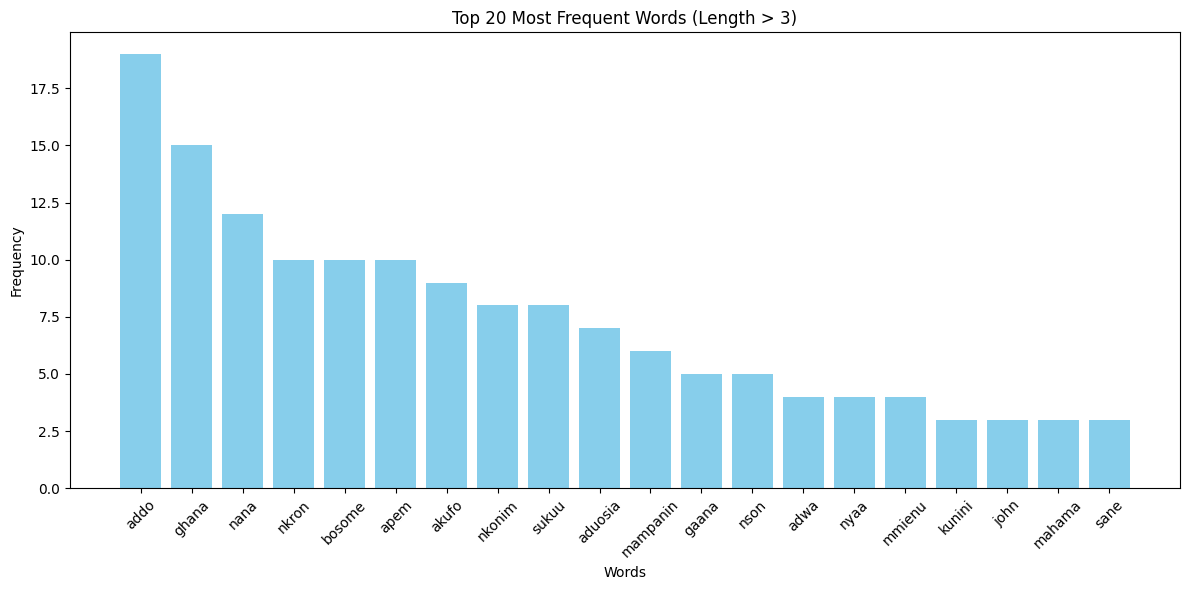

✅ Frequency data saved to word_frequency.csv


In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import csv

def word_frequency_analysis(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().lower()

    # Extract words (only alphabetic sequences)
    words = re.findall(r'\b[a-z]+\b', text)

    # Filter out words with length 2 or 3
    filtered_words = [w for w in words if len(w) > 3]

    freq = Counter(filtered_words)
    return freq

def plot_frequency(freq, top_n=20):
    most_common = freq.most_common(top_n)
    words, counts = zip(*most_common)

    plt.figure(figsize=(12, 6))
    plt.bar(words, counts, color='skyblue')
    plt.title(f'Top {top_n} Most Frequent Words (Length > 3)')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def save_frequency_csv(freq, output_csv):
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['word', 'frequency'])
        for word, count in freq.most_common():
            writer.writerow([word, count])
    print(f"✅ Frequency data saved to {output_csv}")

if __name__ == "__main__":
    input_file = "Nana_corpus.txt"       # Your cleaned text file
    output_csv = "word_frequency.csv"    # CSV output file

    freq = word_frequency_analysis(input_file)
    plot_frequency(freq, top_n=20)
    save_frequency_csv(freq, output_csv)


------------------------------------------------------------------------

## 5. Perform sentiment analyisis (Google Translate API)

In [ ]:
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt
import nltk
import getpass
import json

# New imports for sentiment model
from transformers import pipeline

nltk.download('punkt', quiet=True)

def translate_text(text, source="ak", target="en", api_key=None, max_retries=3):
    """
    Translate text from source language to target language using Google Translate API.
    source: ISO 639-1 code (Akan/Twi is 'ak', English is 'en')
    api_key: Google Cloud API key for Cloud Translation
    """
    url = f"https://translation.googleapis.com/language/translate/v2"
    if len(text) > 1000:
        text = text[:1000]
    params = {
        'q': text,
        'source': source,
        'target': target,
        'format': 'text',
        'key': api_key
    }
    for attempt in range(max_retries):
        try:
            response = requests.post(url, data=params, timeout=30)
            if response.status_code == 200:
                resp_json = response.json()
                return resp_json["data"]["translations"][0]["translatedText"]
            else:
                print(f"API error {response.status_code}: {response.text}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request failed (attempt {attempt+1}): {e}")
        time.sleep(2 ** attempt)
    return None

def classify_sentiment_distilbert(model, text):
    """
    Sentiment classification using HuggingFace distilbert-base-uncased-finetuned-sst-2-english pipeline.
    Returns "Positive" or "Negative".
    """
    try:
        results = model(text)
        label = results[0]['label']
        if label == "POSITIVE":
            return "Positive"
        elif label == "NEGATIVE":
            return "Negative"
        else:
            return "Neutral"
    except Exception as e:
        print(f"Sentiment model error: {e}")
        return "Unknown"

def main():
    # Prompt for Google Translate API key securely
    api_key = getpass.getpass("Enter your Google Cloud Translation API key: ")

    input_txt = "Nana_corpus.txt"          # Your input text file (one sentence per line)
    output_csv = "twi_translated_sentiment.csv"

    # Load sentiment model (downloaded on first use)
    print("Loading sentiment analysis model...")
    sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Read lines from text file
    with open(input_txt, 'r', encoding='utf-8') as f:
        twi_sentences = [line.strip() for line in f if line.strip()]

    results = {
        "Twi_Sentence": [],
        "English_Translation": [],
        "Sentiment": []
    }

    print(f"Translating and analyzing {len(twi_sentences)} sentences...")

    for idx, twi_text in enumerate(twi_sentences, 1):
        print(f"Translating sentence {idx}: {twi_text[:50]}...")
        translation = translate_text(twi_text, source="ak", target="en", api_key=api_key)
        if not translation:
            translation = "[Translation Failed]"

        if translation != "[Translation Failed]":
            sentiment = classify_sentiment_distilbert(sentiment_model, translation)
        else:
            sentiment = "Unknown"

        results["Twi_Sentence"].append(twi_text)
        results["English_Translation"].append(translation)
        results["Sentiment"].append(sentiment)

        time.sleep(1)  # To respect API rate limits

    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nSaved translated sentences and sentiment to {output_csv}")

    # Plot sentiment distribution
    sentiment_counts = df["Sentiment"].value_counts()
    labels = sentiment_counts.index.tolist()
    sizes = sentiment_counts.values.tolist()

    plt.figure(figsize=(7,7))
    colors = ['#66b3ff','#ff9999','#99ff99','#ffcc99']
    plt.pie(sizes, labels=labels, colors=colors[:len(labels)], autopct='%1.1f%%', startangle=140)
    plt.title("Sentiment Distribution of Translated Sentences")
    plt.axis('equal')
    plt.show()

if __name__ == "__main__":
    main()

KeyboardInterrupt: Interrupted by user

------------------------------------------------------------------------

## 5. Perform sentiment analyisis (Ghana NLP API)

In [ ]:
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt
import nltk
import getpass
from transformers import pipeline

nltk.download('punkt', quiet=True)

def translate_text_ghananlp(text, lang_pair="tw-en", api_key=None, max_retries=3):
    """
    Translate text from Twi to English using Ghana NLP API.
    lang_pair: "tw-en" for Twi to English.
    api_key: Ghana NLP API key (if required).
    """
    url = "https://translation-api.ghananlp.org/v1/translate"
    if len(text) > 1000:
        text = text[:1000]
    payload = {"in": text, "lang": lang_pair}
    headers = {"Content-Type": "application/json", "Cache-Control": "no-cache"}
    if api_key:
        headers["Ocp-Apim-Subscription-Key"] = api_key

    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=payload, headers=headers, timeout=30)
            if response.status_code == 200:
                return response.text.strip('"')
            else:
                print(f"API error {response.status_code}: {response.text}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Request failed (attempt {attempt+1}): {e}")
        time.sleep(2 ** attempt)
    return None

def classify_sentiment_distilbert(model, text):
    """
    Sentiment classification using HuggingFace distilbert-base-uncased-finetuned-sst-2-english pipeline.
    Returns "Positive" or "Negative".
    """
    try:
        results = model(text)
        label = results[0]['label']
        if label == "POSITIVE":
            return "Positive"
        elif label == "NEGATIVE":
            return "Negative"
        else:
            return "Neutral"
    except Exception as e:
        print(f"Sentiment model error: {e}")
        return "Unknown"

def main():
    # Prompt for Ghana NLP API key securely (if required)
    api_key = getpass.getpass("Enter your Ghana NLP subscription key (press Enter if not required): ")

    input_txt = "Nana_corpus.txt"          # Your input text file (one sentence per line)
    output_csv = "twi_translated_sentiment.csv"

    # Load sentiment model
    print("Loading sentiment analysis model...")
    sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Read lines from text file
    with open(input_txt, 'r', encoding='utf-8') as f:
        twi_sentences = [line.strip() for line in f if line.strip()]

    results = {
        "Twi_Sentence": [],
        "English_Translation": [],
        "Sentiment": []
    }

    print(f"Translating and analyzing {len(twi_sentences)} sentences...")

    for idx, twi_text in enumerate(twi_sentences, 1):
        print(f"Translating sentence {idx}: {twi_text[:50]}...")
        translation = translate_text_ghananlp(twi_text, lang_pair="tw-en", api_key=api_key)
        if not translation:
            translation = "[Translation Failed]"

        if translation != "[Translation Failed]":
            sentiment = classify_sentiment_distilbert(sentiment_model, translation)
        else:
            sentiment = "Unknown"

        results["Twi_Sentence"].append(twi_text)
        results["English_Translation"].append(translation)
        results["Sentiment"].append(sentiment)

        time.sleep(1)  # To respect API rate limits

    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nSaved translated sentences and sentiment to {output_csv}")

    # Plot sentiment distribution
    sentiment_counts = df["Sentiment"].value_counts()
    labels = sentiment_counts.index.tolist()
    sizes = sentiment_counts.values.tolist()

    plt.figure(figsize=(7,7))
    colors = ['#66b3ff','#ff9999','#99ff99','#ffcc99']
    plt.pie(sizes, labels=labels, colors=colors[:len(labels)], autopct='%1.1f%%', startangle=140)
    plt.title("Sentiment Distribution of Translated Sentences")
    plt.axis('equal')
    plt.show()

if __name__ == "__main__":
    main()

KeyboardInterrupt: Interrupted by user